# Imbalanced Text Classification - Disaster Tweets

**Course:** CS3012E Artificial Intelligence  
**Team Members:** Gowri Sankar P, 
                 Neeraj S,
                 Pankaj Kumar, 
                 Nithin R, 
                 Naveena Mariya Johnson

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("dataset.csv") 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        11370 non-null  int64 
 1   keyword   11370 non-null  object
 2   location  7952 non-null   object
 3   text      11370 non-null  object
 4   target    11370 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 444.3+ KB


In [43]:
df['target'].value_counts()

target
0    9256
1    2114
Name: count, dtype: int64

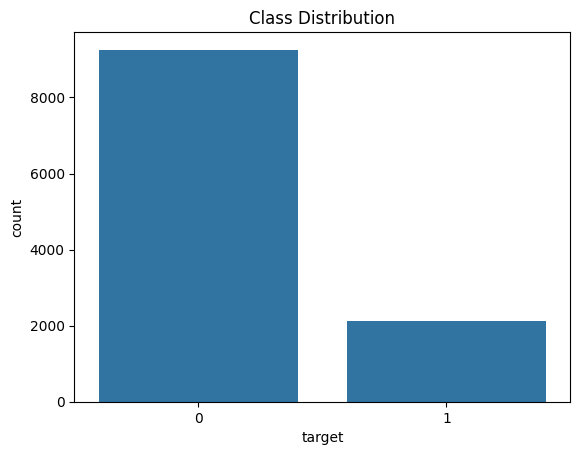

In [44]:
sns.countplot(x='target', data=df)
plt.title("Class Distribution")
plt.show()

In [33]:
#cleaning

import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import emoji
import urllib.parse
import re # Regular expressions
import unicodedata

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4') # Open Multilingual Wordnet (for lemmatization)

def clean_text(text):
    text = urllib.parse.unquote(text) # Fix encoding issues
    text = text.lower() 
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    text = emoji.demojize(text) # Convert emojis to text
    text = re.sub('\W+',' ',text) # Remove all non-word characters
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore') # Normalize unicode to ascii
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and numbers

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    cleaned_text = ' '.join(cleaned_words)

    return cleaned_text
    

df['clean_text'] = (
    df['text']
    # .fillna('') 
    .astype(str)
    # .agg(' '.join, axis=1) 
    .str.replace(r'\s+', ' ', regex=True) # Replace multiple spaces with a single space
    .str.strip() # Remove leading and trailing whitespace
    .apply(clean_text)
)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/nithinraj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/nithinraj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/nithinraj/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [34]:
#TF-IDF
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['target']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42 # 70-30 split
)

### Part A: witout imbalance handling

In [36]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.99      0.92      2777
           1       0.87      0.34      0.49       634

    accuracy                           0.87      3411
   macro avg       0.87      0.66      0.71      3411
weighted avg       0.87      0.87      0.84      3411



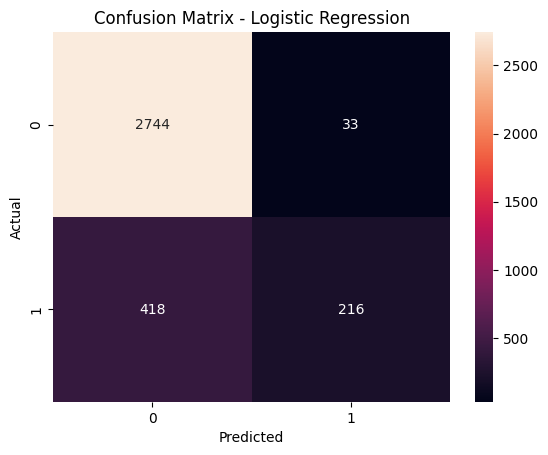

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [39]:
from sklearn.metrics import roc_auc_score

y_prob = lr.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.9041768288180628


In [44]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, max_depth=10)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90      2777
           1       1.00      0.02      0.03       634

    accuracy                           0.82      3411
   macro avg       0.91      0.51      0.47      3411
weighted avg       0.85      0.82      0.74      3411



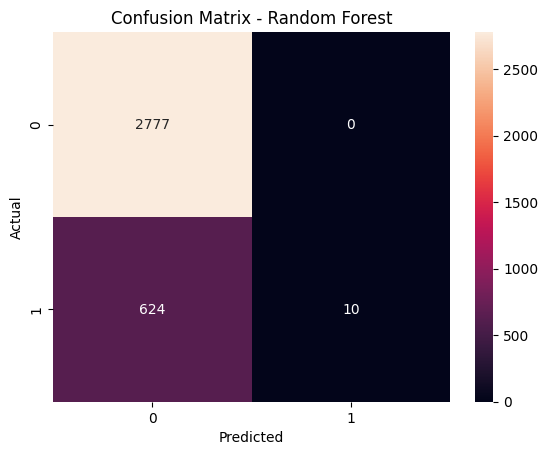

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

ROC-AUC: 0.8321396237003144


In [43]:
#NN Input → 64 → 32 → 16 → Output (sigmoid)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

I0000 00:00:1775289616.462873   84411 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775289616.640663   84411 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775289621.898914   84411 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [47]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

E0000 00:00:1775290034.186628   84411 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [48]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [113]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
 13/224 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9984 - loss: 0.0013     

W0000 00:00:1775291355.282724   84411 cpu_allocator_impl.cc:82] Allocation of 143260000 exceeds 10% of free system memory.


224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9978 - loss: 0.0032 - val_accuracy: 0.8606 - val_loss: 1.0118
Epoch 2/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9975 - loss: 0.0032 - val_accuracy: 0.8618 - val_loss: 1.0230
Epoch 3/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9973 - loss: 0.0032 - val_accuracy: 0.8618 - val_loss: 1.0164
Epoch 4/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9978 - loss: 0.0031 - val_accuracy: 0.8769 - val_loss: 1.0652
Epoch 5/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9982 - loss: 0.0031 - val_accuracy: 0.8681 - val_loss: 1.0876
Epoch 6/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9976 - loss: 0.0032 - val_accuracy: 0.8693 - val_loss: 1.0999
Epoch 7/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9979 - loss: 0.0033 - val_accuracy: 0.8706 - val_loss: 1.0830
Epoch 8/10
224/224 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9980 - loss: 0.0032 - val_accuracy: 0.8668 - val_

In [110]:
y_prob_nn = model.predict(X_test)
y_pred_nn = (y_prob_nn > 0.5).astype(int)

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [111]:
print(classification_report(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92      2777
           1       0.65      0.62      0.63       634

    accuracy                           0.87      3411
   macro avg       0.78      0.77      0.78      3411
weighted avg       0.86      0.87      0.87      3411



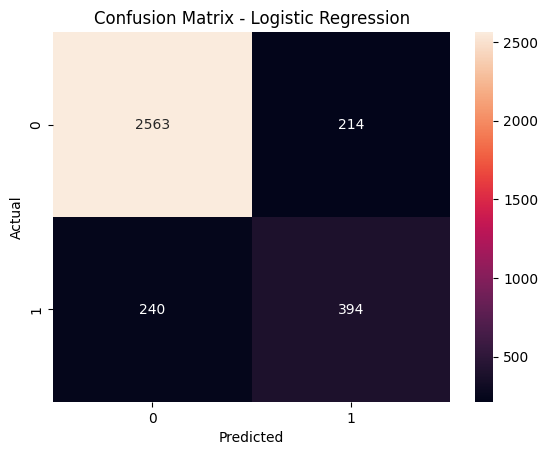

In [112]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [86]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nn))

ROC-AUC: 0.8626249419238018


In [64]:
#WITH DROPOUT
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [65]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [66]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8215 - loss: 0.4365 - val_accuracy: 0.8802 - val_loss: 0.3413
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9062 - loss: 0.2437 - val_accuracy: 0.8901 - val_loss: 0.3190
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9444 - loss: 0.1506 - val_accuracy: 0.8791 - val_loss: 0.3758
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9686 - loss: 0.0925 - val_accuracy: 0.8725 - val_loss: 0.4385
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9809 - loss: 0.0583 - val_accuracy: 0.8703 - val_loss: 0.5232
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9884 - loss: 0.0365 - val_accuracy: 0.8703 - val_loss: 0.6381
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9922 - loss: 0.0259 - val_accuracy: 0.8604 - val_loss: 0.6942
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9946 - loss: 0.0188 - val_accuracy: 0.

In [67]:
y_prob_nn = model.predict(X_test)
y_pred_nn = (y_prob_nn > 0.5).astype(int)

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [68]:
print(classification_report(y_test, y_pred_nn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_nn))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      1851
           1       0.71      0.57      0.63       423

    accuracy                           0.88      2274
   macro avg       0.81      0.76      0.78      2274
weighted avg       0.87      0.88      0.87      2274

ROC-AUC: 0.8593233738583578


In [69]:
#Part B WITH imbalance handling 

In [54]:
#SMOTE
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

In [55]:
import pandas as pd
print(pd.Series(y_train_sm).value_counts())

target
0    6479
1    6479
Name: count, dtype: int64


In [56]:
# Logistic Regression with SMOTE
lr_sm = LogisticRegression()
lr_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = lr_sm.predict(X_test)

print(classification_report(y_test, y_pred_sm))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_sm))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92      2777
           1       0.62      0.69      0.66       634

    accuracy                           0.87      3411
   macro avg       0.78      0.80      0.79      3411
weighted avg       0.87      0.87      0.87      3411

ROC-AUC: 0.798681201714398


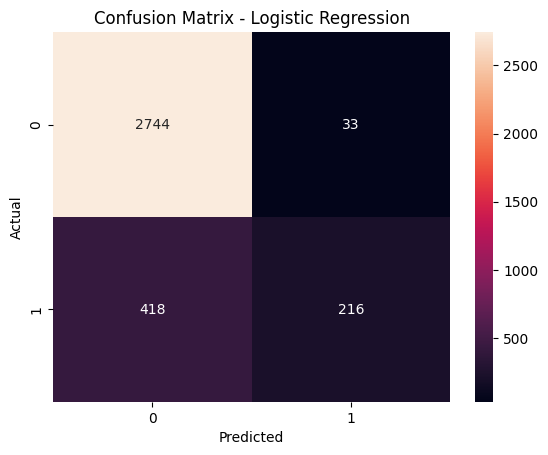

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
#random forest with SMOTE
rf_sm = RandomForestClassifier(n_estimators=50, max_depth=10)
rf_sm.fit(X_train_sm, y_train_sm)

y_pred_rf_sm = rf_sm.predict(X_test)
print(classification_report(y_test, y_pred_rf_sm))
y_prob_rf_sm = rf_sm.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_sm))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      2777
           1       0.65      0.44      0.52       634

    accuracy                           0.85      3411
   macro avg       0.76      0.69      0.72      3411
weighted avg       0.84      0.85      0.84      3411

ROC-AUC: 0.8278377251624146


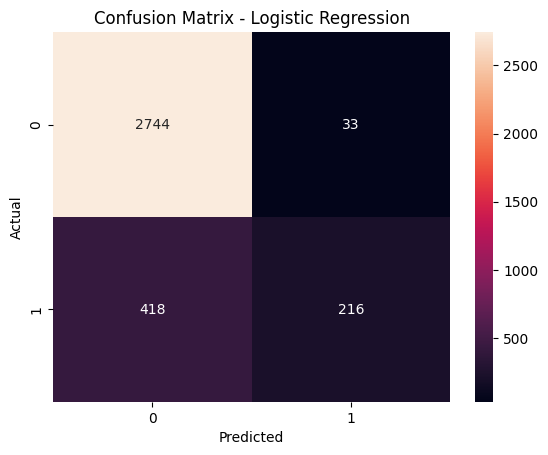

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [74]:
#NN with SMOTE
model_sm = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_sm.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_sm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_sm.fit(
    X_train_sm, y_train_sm,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8524 - loss: 0.3287 - val_accuracy: 0.9662 - val_loss: 0.1109
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9651 - loss: 0.1018 - val_accuracy: 0.9905 - val_loss: 0.0415
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9892 - loss: 0.0389 - val_accuracy: 0.9905 - val_loss: 0.0314
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9942 - loss: 0.0184 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9967 - loss: 0.0113 - val_accuracy: 0.9953 - val_loss: 0.0128
Epoch 6/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9973 - loss: 0.0085 - val_accuracy: 0.9986 - val_loss: 0.0079
Epoch 7/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9972 - loss: 0.0077 - val_accuracy: 0.9993 - val_loss: 0.0026
Epoch 8/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9974 - loss: 0.0082 - val_accuracy: 0.

In [75]:
y_prob_nn_sm = model_sm.predict(X_test)
y_pred_nn_sm = (y_prob_nn_sm > 0.5).astype(int)

print(classification_report(y_test, y_pred_nn_sm))

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1851
           1       0.69      0.61      0.65       423

    accuracy                           0.88      2274
   macro avg       0.80      0.77      0.79      2274
weighted avg       0.87      0.88      0.87      2274



In [78]:
#LOG REG WITH CLASS WEIGHTS
lr_w = LogisticRegression(class_weight='balanced')
lr_w.fit(X_train, y_train)

y_pred_w = lr_w.predict(X_test)

print(classification_report(y_test, y_pred_w))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_w))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1851
           1       0.59      0.75      0.66       423

    accuracy                           0.86      2274
   macro avg       0.77      0.82      0.79      2274
weighted avg       0.88      0.86      0.86      2274

ROC-AUC: 0.8176412213447974


In [80]:
rf_w = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced')
rf_w.fit(X_train, y_train)

y_pred_rf_w = rf_w.predict(X_test)

print(classification_report(y_test, y_pred_rf_w))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf_w))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      1851
           1       0.58      0.49      0.53       423

    accuracy                           0.84      2274
   macro avg       0.73      0.70      0.72      2274
weighted avg       0.83      0.84      0.83      2274

ROC-AUC: 0.7032503036503175


In [82]:
#NN with class weights
class_weights = {0: 1, 1: 4}  # because imbalance ~4:1


In [83]:
model_w = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_w.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_w.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weights
)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8169 - loss: 0.8943 - val_accuracy: 0.7593 - val_loss: 0.4691
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8919 - loss: 0.4172 - val_accuracy: 0.8319 - val_loss: 0.3982
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9508 - loss: 0.2021 - val_accuracy: 0.8549 - val_loss: 0.4429
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9740 - loss: 0.0987 - val_accuracy: 0.8637 - val_loss: 0.5248
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9864 - loss: 0.0553 - val_accuracy: 0.8659 - val_loss: 0.6123
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9918 - loss: 0.0356 - val_accuracy: 0.8670 - val_loss: 0.6460
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9944 - loss: 0.0235 - val_accuracy: 0.8670 - val_loss: 0.7234
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9961 - loss: 0.0165 - val_accuracy: 0.

In [84]:
y_prob_nn_w = model_w.predict(X_test)
y_pred_nn_w = (y_prob_nn_w > 0.5).astype(int)

print(classification_report(y_test, y_pred_nn_w))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_nn_w))

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1851
           1       0.70      0.57      0.62       423

    accuracy                           0.87      2274
   macro avg       0.80      0.75      0.77      2274
weighted avg       0.87      0.87      0.87      2274

ROC-AUC: 0.7544129874210223
